# ***MOUNT GOOGLE DRIVE***

In [43]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ***IMPORTS***

In [44]:
import os
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from glob import glob
from sklearn.metrics import confusion_matrix
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

# ***PATHS  (EDIT THESE ONLY)***

In [45]:
path="/content/drive/MyDrive/Project work/Dataset/lgg-mri-segmentation/lgg_structured"
print(os.path.exists(path))

True


In [46]:
TRAIN_IMG_DIR  = os.path.join(path,"train/images")
TRAIN_MASK_DIR = os.path.join(path,"train/masks")
print("Train images exists :", os.path.exists(TRAIN_IMG_DIR))
print("Train masks  exists :", os.path.exists(TRAIN_MASK_DIR))

Train images exists : True
Train masks  exists : True


In [47]:
VAL_IMG_DIR    = os.path.join(path,"val/images")
VAL_MASK_DIR   = os.path.join(path,"val/masks")
print("Val   images exists :", os.path.exists(VAL_IMG_DIR))
print("Val   masks  exists :", os.path.exists(VAL_MASK_DIR))

Val   images exists : True
Val   masks  exists : True


In [48]:
TEST_IMG_DIR   = os.path.join(path,"test/images")
TEST_MASK_DIR  = os.path.join(path,"test/masks")
print("Test  images exists :", os.path.exists(TEST_IMG_DIR))
print("Test  masks  exists :", os.path.exists(TEST_MASK_DIR))

Test  images exists : True
Test  masks  exists : True


In [49]:
MODEL_SAVE_PATH = "/content/drive/MyDrive/Project work/models/Segmentation/unet_lgg_segmentation_u-net.keras"
                                         #Project work\models\Segmentation

# ***CONFIG***

In [50]:
IMG_SIZE    = 256
BATCH_SIZE  = 16
SEED        = 42
EPOCHS      = 50
TARGET_DICE = 0.75
GRAPHS      = []

# ***DATA LOADING***

In [51]:
train_images = sorted(glob(os.path.join(TRAIN_IMG_DIR,  "*")))
train_masks  = sorted(glob(os.path.join(TRAIN_MASK_DIR, "*")))

val_images   = sorted(glob(os.path.join(VAL_IMG_DIR,    "*")))
val_masks    = sorted(glob(os.path.join(VAL_MASK_DIR,   "*")))

test_images  = sorted(glob(os.path.join(TEST_IMG_DIR,   "*")))
test_masks   = sorted(glob(os.path.join(TEST_MASK_DIR,  "*")))

print(f"Train : {len(train_images)} images | {len(train_masks)} masks")
print(f"Val   : {len(val_images)} images | {len(val_masks)} masks")
print(f"Test  : {len(test_images)} images | {len(test_masks)} masks")

Train : 3133 images | 3133 masks
Val   : 409 images | 409 masks
Test  : 387 images | 387 masks


# ***PREPROCESSING***

In [52]:


# Load image → grayscale → normalize to [0, 1]
def load_image(img_path):
    img = cv2.imread(img_path.numpy().decode(), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)
    return img

# Load mask → binary [0, 1]
def load_mask(mask_path):
    mask = cv2.imread(mask_path.numpy().decode(), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 127).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)
    return mask

def parse_sample(img_path, mask_path):
    img  = tf.py_function(load_image, [img_path], tf.float32)
    mask = tf.py_function(load_mask,  [mask_path], tf.float32)
    img.set_shape( [IMG_SIZE, IMG_SIZE, 1])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])
    return img, mask

# ***AUGMENTATION***

In [53]:

def augment_sample(img, mask):

    # Random horizontal flip
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    # Random vertical flip
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    # Random rotation — both image and mask
    k    = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img  = tf.image.rot90(img,  k)
    mask = tf.image.rot90(mask, k)

    # Brightness — image only
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.clip_by_value(img, 0.0, 1.0)

    # Contrast — image only
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)

    return img, mask

# ***DATA PIPELINE***

In [54]:

AUTOTUNE = tf.data.AUTOTUNE

# Train
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_masks))
train_ds = train_ds.shuffle(len(train_images), seed=SEED)
train_ds = train_ds.map(parse_sample,   num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment_sample, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.cache()
train_ds = train_ds.prefetch(AUTOTUNE)

# Val
val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_masks))
val_ds = val_ds.map(parse_sample, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.cache()
val_ds = val_ds.prefetch(AUTOTUNE)

# Test
test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_masks))
test_ds = test_ds.map(parse_sample, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Datasets ready.")

Datasets ready.


# ***VERIFY SAMPLES***

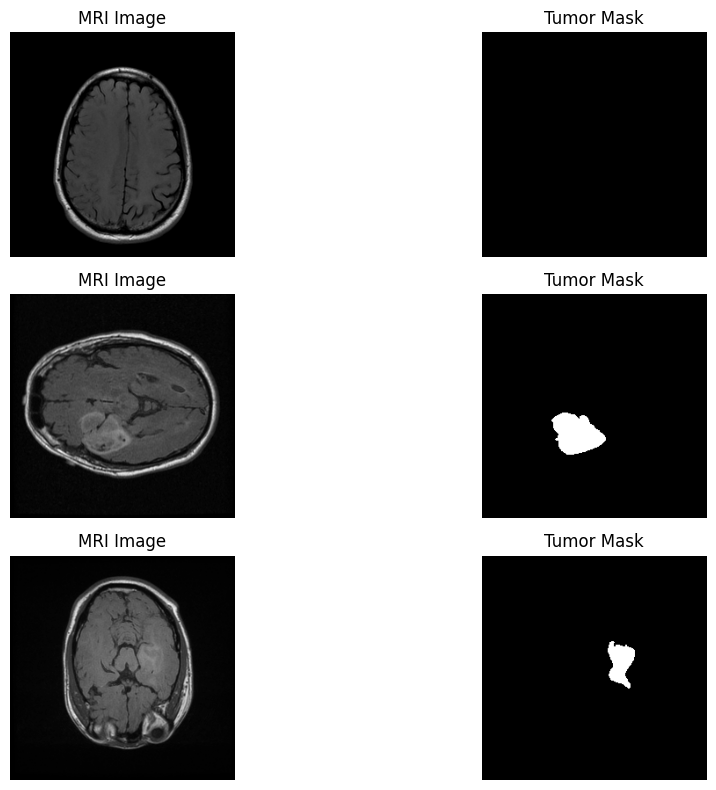

In [55]:
plt.figure(figsize=(12, 8))
for imgs, masks in train_ds.take(1):
    for i in range(3):
        plt.subplot(3, 2, i * 2 + 1)
        plt.imshow(imgs[i].numpy().squeeze(), cmap="gray")
        plt.title("MRI Image")
        plt.axis("off")

        plt.subplot(3, 2, i * 2 + 2)
        plt.imshow(masks[i].numpy().squeeze(), cmap="gray")
        plt.title("Tumor Mask")
        plt.axis("off")

plt.tight_layout()
plt.show()


# ***LOSS & METRICS***

In [56]:


def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(tf.cast(y_pred, tf.float32))
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce  = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(tf.cast(y_pred, tf.float32))
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# ***BUILD U-NET MODEL***

In [57]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

***ENCODER***

In [58]:

# Block 1
e1 = tf.keras.layers.Conv2D(32, 3, padding="same")(inputs)
e1 = tf.keras.layers.BatchNormalization()(e1)
e1 = tf.keras.layers.Activation("relu")(e1)
e1 = tf.keras.layers.Conv2D(32, 3, padding="same")(e1)
e1 = tf.keras.layers.BatchNormalization()(e1)
e1 = tf.keras.layers.Activation("relu")(e1)
p1 = tf.keras.layers.MaxPooling2D(2)(e1)                      # 256 → 128

# Block 2
e2 = tf.keras.layers.Conv2D(64, 3, padding="same")(p1)
e2 = tf.keras.layers.BatchNormalization()(e2)
e2 = tf.keras.layers.Activation("relu")(e2)
e2 = tf.keras.layers.Conv2D(64, 3, padding="same")(e2)
e2 = tf.keras.layers.BatchNormalization()(e2)
e2 = tf.keras.layers.Activation("relu")(e2)
p2 = tf.keras.layers.MaxPooling2D(2)(e2)                      # 128 → 64

# Block 3
e3 = tf.keras.layers.Conv2D(128, 3, padding="same")(p2)
e3 = tf.keras.layers.BatchNormalization()(e3)
e3 = tf.keras.layers.Activation("relu")(e3)
e3 = tf.keras.layers.Conv2D(128, 3, padding="same")(e3)
e3 = tf.keras.layers.BatchNormalization()(e3)
e3 = tf.keras.layers.Activation("relu")(e3)
p3 = tf.keras.layers.MaxPooling2D(2)(e3)                      # 64 → 32

# Block 4
e4 = tf.keras.layers.Conv2D(256, 3, padding="same")(p3)
e4 = tf.keras.layers.BatchNormalization()(e4)
e4 = tf.keras.layers.Activation("relu")(e4)
e4 = tf.keras.layers.Conv2D(256, 3, padding="same")(e4)
e4 = tf.keras.layers.BatchNormalization()(e4)
e4 = tf.keras.layers.Activation("relu")(e4)
p4 = tf.keras.layers.MaxPooling2D(2)(e4)                      # 32 → 16

***BOTTLENECK***

In [59]:

b = tf.keras.layers.Conv2D(512, 3, padding="same")(p4)
b = tf.keras.layers.BatchNormalization()(b)
b = tf.keras.layers.Activation("relu")(b)
b = tf.keras.layers.Conv2D(512, 3, padding="same")(b)
b = tf.keras.layers.BatchNormalization()(b)
b = tf.keras.layers.Activation("relu")(b)

***DECODER***

In [60]:
# Block 1
d1 = tf.keras.layers.Conv2DTranspose(256, 2, strides=2, padding="same")(b)
d1 = tf.keras.layers.Concatenate()([d1, e4])
d1 = tf.keras.layers.Conv2D(256, 3, padding="same")(d1)
d1 = tf.keras.layers.BatchNormalization()(d1)
d1 = tf.keras.layers.Activation("relu")(d1)
d1 = tf.keras.layers.Conv2D(256, 3, padding="same")(d1)
d1 = tf.keras.layers.BatchNormalization()(d1)
d1 = tf.keras.layers.Activation("relu")(d1)

# Block 2
d2 = tf.keras.layers.Conv2DTranspose(128, 2, strides=2, padding="same")(d1)
d2 = tf.keras.layers.Concatenate()([d2, e3])
d2 = tf.keras.layers.Conv2D(128, 3, padding="same")(d2)
d2 = tf.keras.layers.BatchNormalization()(d2)
d2 = tf.keras.layers.Activation("relu")(d2)
d2 = tf.keras.layers.Conv2D(128, 3, padding="same")(d2)
d2 = tf.keras.layers.BatchNormalization()(d2)
d2 = tf.keras.layers.Activation("relu")(d2)

# Block 3
d3 = tf.keras.layers.Conv2DTranspose(64, 2, strides=2, padding="same")(d2)
d3 = tf.keras.layers.Concatenate()([d3, e2])
d3 = tf.keras.layers.Conv2D(64, 3, padding="same")(d3)
d3 = tf.keras.layers.BatchNormalization()(d3)
d3 = tf.keras.layers.Activation("relu")(d3)
d3 = tf.keras.layers.Conv2D(64, 3, padding="same")(d3)
d3 = tf.keras.layers.BatchNormalization()(d3)
d3 = tf.keras.layers.Activation("relu")(d3)

# Block 4
d4 = tf.keras.layers.Conv2DTranspose(32, 2, strides=2, padding="same")(d3)
d4 = tf.keras.layers.Concatenate()([d4, e1])
d4 = tf.keras.layers.Conv2D(32, 3, padding="same")(d4)
d4 = tf.keras.layers.BatchNormalization()(d4)
d4 = tf.keras.layers.Activation("relu")(d4)
d4 = tf.keras.layers.Conv2D(32, 3, padding="same")(d4)
d4 = tf.keras.layers.BatchNormalization()(d4)
d4 = tf.keras.layers.Activation("relu")(d4)

***OUTPUT***

In [61]:


outputs = tf.keras.layers.Conv2D(1, 1, activation="sigmoid", padding="same")(d4)

model = tf.keras.Model(inputs, outputs, name="UNet")

model.summary()

Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 256, 256,  │        320 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_38[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_36       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 256, 256,  │      9,248 │ activation_36[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_37       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 128, 128,  │          0 │ activation_37[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_38       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 128, 128,  │     36,928 │ activation_38[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_39       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 64, 64,    │          0 │ activation_39[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_9[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_42[0][0] 

 Total params: 7,771,297 (29.65 MB)

 Trainable params: 7,765,409 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

# ***CALLBACKS***

In [62]:


callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "best_unet_temp.h5",
        monitor="val_dice_coefficient",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coefficient",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coefficient",
        mode="max",
        patience=3,
        factor=0.3,
        min_lr=1e-7,
        verbose=1
    )
]


# ***PHASE 1 — INITIAL TRAINING***

In [63]:


print("Phase 1 — Training...")

model.compile(
    optimizer=tf.keras.optimizers.AdamW(1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_score]
)

hist_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

model.load_weights("best_unet_temp.h5")
GRAPHS.append(hist_phase1)


Phase 1 — Training...
Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - dice_coefficient: 0.0202 - iou_score: 0.0102 - loss: 1.5771
Epoch 1: val_dice_coefficient improved from -inf to 0.02126, saving model to best_unet_temp.h5


196/196 ━━━━━━━━━━━━━━━━━━━━ 68s 208ms/step - dice_coefficient: 0.0202 - iou_score: 0.0103 - loss: 1.5763 - val_dice_coefficient: 0.0213 - val_iou_score: 0.0109 - val_loss: 1.4015 - learning_rate: 1.0000e-04
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - dice_coefficient: 0.0236 - iou_score: 0.0120 - loss: 1.2631
Epoch 2: val_dice_coefficient improved from 0.02126 to 0.02261, saving model to best_unet_temp.h5


196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - dice_coefficient: 0.0236 - iou_score: 0.0120 - loss: 1.2631 - val_dice_coefficient: 0.0226 - val_iou_score: 0.0116 - val_loss: 1.2478 - learning_rate: 1.0000e-04
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - dice_coefficient: 0.0287 - iou_score: 0.0146 - loss: 1.2110
Epoch 3: val_dice_coefficient improved from 0.02261 to 0.02468, saving model to best_unet_temp.h5


196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - dice_coefficient: 0.0288 - iou_score: 0.0146 - loss: 1.2109 - val_dice_coefficient: 0.0247 - val_iou_score: 0.0128 - val_loss: 1.2151 - learning_rate: 1.0000e-04
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - dice_coefficient: 0.0362 - iou_score: 0.0185 - loss: 1.1696
Epoch 4: val_dice_coefficient improved from 0.02468 to 0.04528, saving model to best_unet_temp.h5


196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - dice_coefficient: 0.0362 - iou_score: 0.0185 - loss: 1.1696 - val_dice_coefficient: 0.0453 - val_iou_score: 0.0243 - val_loss: 1.1355 - learning_rate: 1.0000e-04
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - dice_coefficient: 0.0504 - iou_score: 0.0261 - loss: 1.1272
Epoch 5: val_dice_coefficient improved from 0.04528 to 0.06054, saving model to best_unet_temp.h5


...

196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - dice_coefficient: 0.2436 - iou_score: 0.1432 - loss: 0.8163 - val_dice_coefficient: 0.1566 - val_iou_score: 0.0985 - val_loss: 0.9193 - learning_rate: 1.0000e-04
Epoch 13/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - dice_coefficient: 0.2998 - iou_score: 0.1826 - loss: 0.7499
Epoch 13: val_dice_coefficient improved from 0.15660 to 0.17672, saving model to best_unet_temp.h5


196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - dice_coefficient: 0.2999 - iou_score: 0.1827 - loss: 0.7499 - val_dice_coefficient: 0.1767 - val_iou_score: 0.1122 - val_loss: 0.9025 - learning_rate: 1.0000e-04
Epoch 14/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - dice_coefficient: 0.3514 - iou_score: 0.2214 - loss: 0.6923
Epoch 14: val_dice_coefficient improved from 0.17672 to 0.21184, saving model to best_unet_temp.h5


196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - dice_coefficient: 0.3515 - iou_score: 0.2214 - loss: 0.6922 - val_dice_coefficient: 0.2118 - val_iou_score: 0.1421 - val_loss: 0.8903 - learning_rate: 1.0000e-04
Epoch 15/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - dice_coefficient: 0.4022 - iou_score: 0.2624 - loss: 0.6369
Epoch 15: val_dice_coefficient did not improve from 0.21184
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - dice_coefficient: 0.4023 - iou_score: 0.2625 - loss: 0.6368 - val_dice_coefficient: 0.2013 - val_iou_score: 0.1365 - val_loss: 0.8626 - learning_rate: 1.0000e-04
Epoch 16/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - dice_coefficient: 0.4467 - iou_score: 0.3003 - loss: 0.5898
Epoch 16: val_dice_coefficient did not improve from 0.21184
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - dice_coefficient: 0.4468 - iou_score: 0.3003 - loss: 0.5897 - val_dice_coefficient: 0.1945 - val_iou_score: 0.1295 - val_loss: 0.8563 - learning_rate: 1.0000e-04
Epoch 17/50
196/196 ━━━━━━━━━━

196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - dice_coefficient: 0.5271 - iou_score: 0.3736 - loss: 0.5051 - val_dice_coefficient: 0.2423 - val_iou_score: 0.1675 - val_loss: 0.8167 - learning_rate: 3.0000e-05
Epoch 19/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - dice_coefficient: 0.5676 - iou_score: 0.4119 - loss: 0.4613
Epoch 19: val_dice_coefficient improved from 0.24234 to 0.24942, saving model to best_unet_temp.h5


196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - dice_coefficient: 0.5677 - iou_score: 0.4119 - loss: 0.4612 - val_dice_coefficient: 0.2494 - val_iou_score: 0.1720 - val_loss: 0.8084 - learning_rate: 3.0000e-05
Epoch 20/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - dice_coefficient: 0.5897 - iou_score: 0.4339 - loss: 0.4379
Epoch 20: val_dice_coefficient did not improve from 0.24942
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - dice_coefficient: 0.5897 - iou_score: 0.4339 - loss: 0.4378 - val_dice_coefficient: 0.2481 - val_iou_score: 0.1713 - val_loss: 0.8118 - learning_rate: 3.0000e-05
Epoch 21/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - dice_coefficient: 0.6088 - iou_score: 0.4537 - loss: 0.4178
Epoch 21: val_dice_coefficient did not improve from 0.24942
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - dice_coefficient: 0.6088 - iou_score: 0.4538 - loss: 0.4178 - val_dice_coefficient: 0.2469 - val_iou_score: 0.1706 - val_loss: 0.8107 - learning_rate: 3.0000e-05
Epoch 22/50
196/196 ━━━━━━━━━━

# ***PHASE 2 — FINE TUNE (if Dice < target)***

In [64]:


best_dice = max(hist_phase1.history["val_dice_coefficient"])
print(f"Best Val Dice : {best_dice:.4f}")

if best_dice < TARGET_DICE:

    print("Dice below target — Running Phase 2...")

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(1e-5),
        loss=bce_dice_loss,
        metrics=[dice_coefficient, iou_score]
    )

    hist_phase2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=callbacks
    )

    model.load_weights("best_unet_temp.h5")
    GRAPHS.append(hist_phase2)

else:
    print(f"Dice ≥ {TARGET_DICE} — Skipping Phase 2")

Best Val Dice : 0.2494
Dice below target — Running Phase 2...
Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - dice_coefficient: 0.5900 - iou_score: 0.4343 - loss: 0.4374
Epoch 1: val_dice_coefficient did not improve from 0.24942
196/196 ━━━━━━━━━━━━━━━━━━━━ 46s 105ms/step - dice_coefficient: 0.5900 - iou_score: 0.4344 - loss: 0.4374 - val_dice_coefficient: 0.2441 - val_iou_score: 0.1683 - val_loss: 0.8103 - learning_rate: 1.0000e-05
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - dice_coefficient: 0.6000 - iou_score: 0.4447 - loss: 0.4267
Epoch 2: val_dice_coefficient did not improve from 0.24942
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - dice_coefficient: 0.6001 - iou_score: 0.4447 - loss: 0.4266 - val_dice_coefficient: 0.2443 - val_iou_score: 0.1680 - val_loss: 0.8070 - learning_rate: 1.0000e-05
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - dice_coefficient: 0.6086 - iou_score: 0.4536 - loss: 0.4175
Epoch 3: val_dice_coefficient did not improve from 0.24942
19

# ***GRAPH***

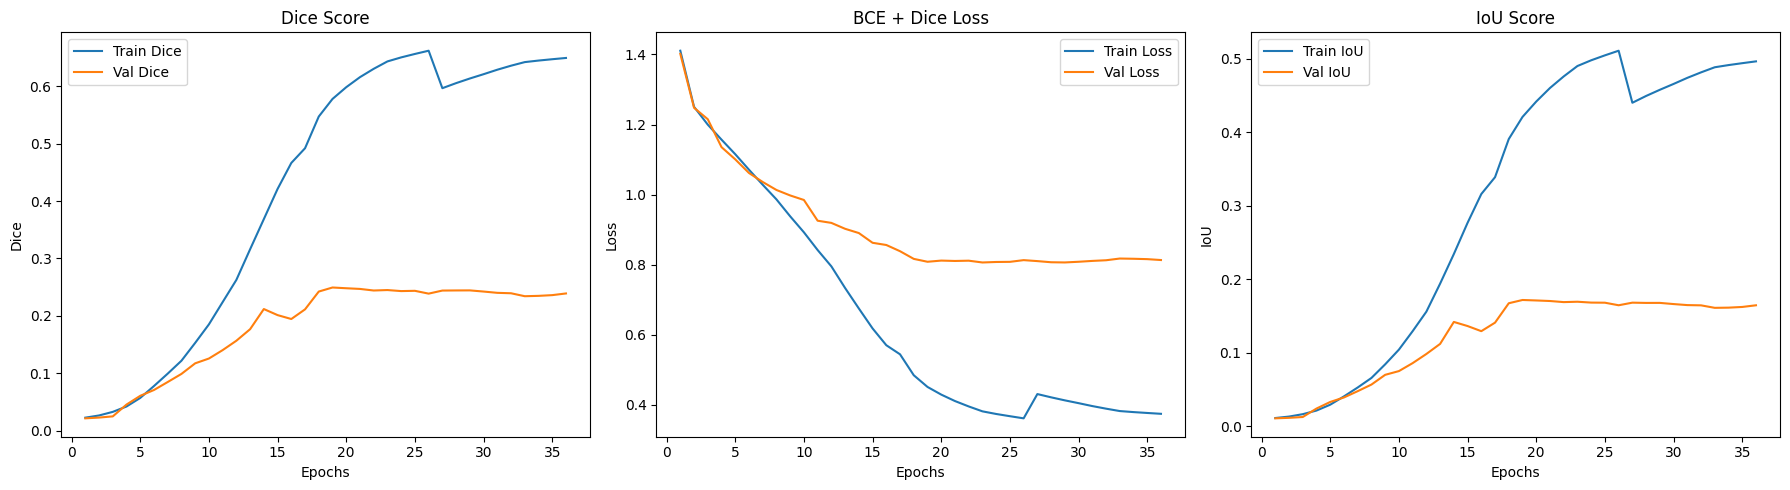

In [65]:


dice_train = []
dice_val   = []
loss_train = []
loss_val   = []
iou_train  = []
iou_val    = []

for h in GRAPHS:
    dice_train += h.history["dice_coefficient"]
    dice_val   += h.history["val_dice_coefficient"]
    loss_train += h.history["loss"]
    loss_val   += h.history["val_loss"]
    iou_train  += h.history["iou_score"]
    iou_val    += h.history["val_iou_score"]

epochs = range(1, len(dice_train) + 1)

plt.figure(figsize=(18, 5))

# Dice
plt.subplot(1, 3, 1)
plt.plot(epochs, dice_train, label="Train Dice")
plt.plot(epochs, dice_val,   label="Val Dice")
plt.title("Dice Score")
plt.xlabel("Epochs")
plt.ylabel("Dice")
plt.legend()

# Loss
plt.subplot(1, 3, 2)
plt.plot(epochs, loss_train, label="Train Loss")
plt.plot(epochs, loss_val,   label="Val Loss")
plt.title("BCE + Dice Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# IoU
plt.subplot(1, 3, 3)
plt.plot(epochs, iou_train, label="Train IoU")
plt.plot(epochs, iou_val,   label="Val IoU")
plt.title("IoU Score")
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.legend()

plt.tight_layout()
plt.show()


# ***EVALUATE***

In [66]:

print("Evaluating on Test Set...")
results = model.evaluate(test_ds)

print(f"\nTest Loss       : {results[0]:.4f}")
print(f"Test Dice Score : {results[1]:.4f}")
print(f"Test IoU Score  : {results[2]:.4f}")

if results[1] > 0.80:
    print("Excellent segmentation model")
elif results[1] > 0.70:
    print("Good segmentation model")
else:
    print("Needs improvement")


Evaluating on Test Set...
25/25 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - dice_coefficient: 0.4069 - iou_score: 0.2800 - loss: 0.6362

Test Loss       : 0.6746
Test Dice Score : 0.3533
Test IoU Score  : 0.2469
Needs improvement


# ***PREDICTION VISUALIZATION***

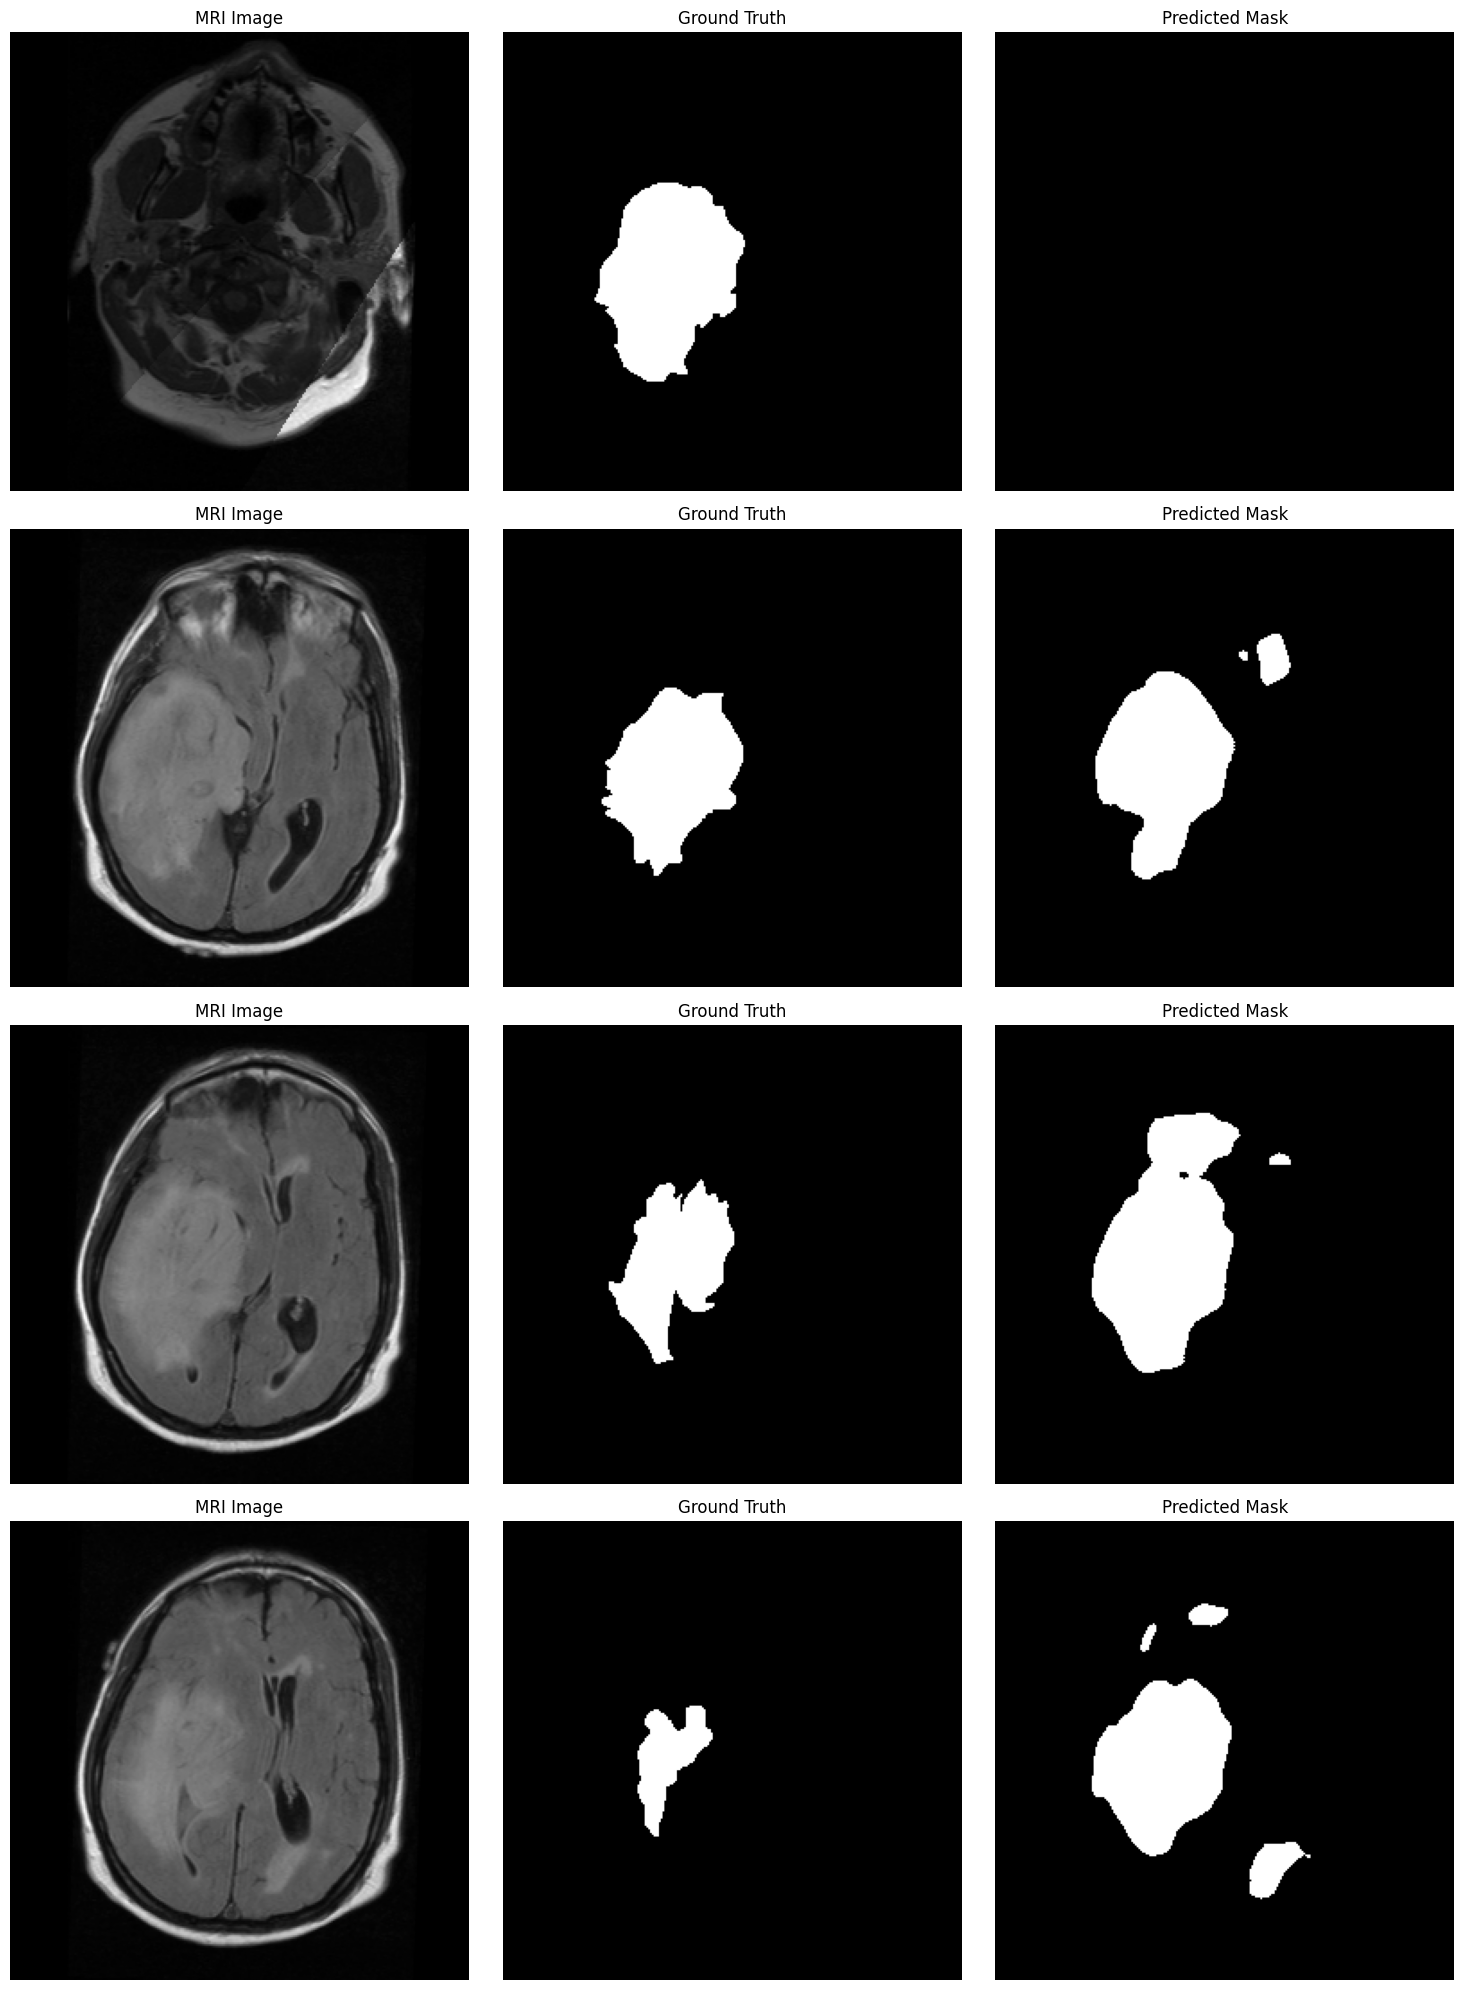

In [67]:
plt.figure(figsize=(15, 20))
for imgs, masks in test_ds.take(1):
    preds        = model.predict(imgs, verbose=0)
    preds_binary = (preds > 0.5).astype(np.float32)

    for i in range(4):
        plt.subplot(4, 3, i * 3 + 1)
        plt.imshow(imgs[i].numpy().squeeze(), cmap="gray")
        plt.title("MRI Image")
        plt.axis("off")

        plt.subplot(4, 3, i * 3 + 2)
        plt.imshow(masks[i].numpy().squeeze(), cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(4, 3, i * 3 + 3)
        plt.imshow(preds_binary[i].squeeze(), cmap="gray")
        plt.title("Predicted Mask")
        plt.axis("off")

plt.tight_layout()
plt.show()

# ***SAVE MODEL***

In [68]:

model.save(MODEL_SAVE_PATH)

print("Model saved at:")
print("Keras :", MODEL_SAVE_PATH)

Model saved at:
Keras : /content/drive/MyDrive/Project work/models/Segmentation/unet_lgg_segmentation_u-net.keras
